In [1]:
import pandas as pd
from pathlib import Path
import re
import numpy as np

from matplotlib.transforms import blended_transform_factory, ScaledTranslation
from paiskintonetools import setup_matplotlib  # type: ignore

setup_matplotlib()

In [2]:
# data_folder = Path("ColourimeterData")
data_folder = Path("../")
regions = ["phantom", "leg", "forearm", "neck", "bicep", "radial"]
proper_name = {
    "phantom": "Phantom",
    "leg": "Leg",
    "forearm": "Radial Artery",
    "forarm": "Radial Artery",
    "foreearm": "Radial Artery",
    "foreaerm": "Radial Artery",
    "radial": "Radial Artery",
    "ulnar": "Ulnar Artery",
    "brachialartery": "Brachial Artery",
    "neck": "Carotid Artery",
    "bicep": "Bicep",
    "calf": "Leg",
    "brachial artery": "Brachial Artery",
    "radius": "Radial Artery",
    "brachial": "Brachial Artery",
}


def get_scan_location(x):
    scan_regions = re.findall("|".join(list(proper_name)), x.lower())
    return proper_name[scan_regions[0]] if len(scan_regions) == 1 else None


def get_pigmented(x):
    # This is wrong.
    if "vitiligo" in x.lower():
        return "Not Pigmented"
    elif "not pigmented" in x.lower():
        return "Not Pigmented"
    elif "pigmented" in x.lower():
        return "Pigmented"
    elif " p " in x.lower():
        return "Pigmented"
    elif " np " in x.lower():
        return "Not Pigmented"
    elif "no pigment" in x.lower():
        return "Not Pigmented"
    elif "pigment" in x.lower():
        return "Pigmented"
    return ""

# 1. Load all the colourimeter files in the data folder, extract the scan names/ID numbers etc.

In [3]:
details = []

for file in data_folder.glob("**/*.cmf"):
    if file.stem[0] == ".":
        continue
    skin_id = file.stem.split(" - ")[-1]
    # print(file)
    df_col = pd.read_table(file, skiprows=2)
    df_col.columns = [str.strip(c) for c in df_col.columns]
    df_col["Region"] = df_col["Label"].apply(get_scan_location)
    df_col["Pigment"] = df_col["Label"].apply(get_pigmented)
    df_col["Side"] = df_col["Label"].apply(
        lambda x: (
            "Left" if "left" in x.lower() else "Right" if "right" in x.lower() else ""
        )
    )
    df_col["SkinID"] = skin_id
    details.append(df_col)

In [4]:
details[0].columns

Index(['Label', 'Date', 'Eryth.', 'Melanin', 'CIE-L*', 'CIE-a*', 'CIE-b*', 'X',
       'Y', 'Z', 'Chroma', 'Hue', 'ITA', 'Gloss', 'sR', 'sG', 'sB', 'CF1',
       'CF2', 'CF3', 'CF4', 'CF5', 'CF6', 'CF7', 'CF8', 'CNIR', 'CCLEAR',
       'GF1', 'GF2', 'GF3', 'GF4', 'GF5', 'GF6', 'GF7', 'GF8', 'GNIR',
       'GCLEAR', 'Calib.', 'Status', 'Region', 'Pigment', 'Side', 'SkinID'],
      dtype='object')

In [5]:
columns = [
    "SkinID",
    "Region",
    "Pigment",
    "Side",
    "ITA",
    "CIE-L*",
    "CIE-a*",
    "CIE-b*",
    "Melanin",
    "Eryth.",
    "sR",
    "sG",
    "sB",
]

df_full = (
    pd.concat(details).sort_values("SkinID").reset_index().drop(index=490)
)  # Note 490 is an outlier.

# df_full.

df = df_full[columns].groupby(columns[:4]).mean().reset_index()

In [6]:
# Manually fix values for the SKIN36
mask = df["SkinID"] == "SKIN36"
mask &= df["Region"] == "Carotid Artery"
mask &= df["Pigment"] != "Not Pigmented"
df.loc[mask, "Pigment"] = "Pigmented"

In [7]:
df = df.sort_values(["SkinID", "Region", "Pigment", "Side"])

In [8]:
df.to_parquet("tables/ITA_raw.parquet")

In [9]:
df

,SkinID,Region,Pigment,Side,ITA,CIE-L*,CIE-a*,CIE-b*,Melanin,Eryth.,sR,sG,sB
0,SKIN01,Bicep,,,70.370,69.762,1.540,7.048,29.626,6.252,192.6,165.0,151.0
1,SKIN01,Carotid Artery,,,54.196,64.894,6.008,10.720,29.234,15.492,187.8,149.2,132.6
2,SKIN01,Leg,,,61.702,64.848,2.532,7.972,34.588,9.366,180.2,151.4,137.0
3,SKIN01,Radial Artery,,,64.518,67.456,1.456,8.276,31.650,7.700,186.4,159.2,142.8
4,SKIN02,Bicep,,,56.256,64.468,2.892,9.660,33.822,10.860,180.8,150.0,133.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,SKIN42,Radial Artery,,,-19.218,43.540,9.488,18.542,53.160,27.328,135.2,93.6,69.0
185,SKIN43,Bicep,,,-13.662,45.290,9.072,19.484,51.670,24.250,139.8,98.0,71.4
186,SKIN43,Carotid Artery,,,-24.828,43.070,10.308,15.072,54.122,28.340,134.2,92.0,73.4
187,SKIN43,Leg,,,-9.066,46.866,8.078,19.618,50.884,21.952,143.2,102.4,74.4


In [10]:
# for n, g in df_full.groupby(columns[:4]):
#     print(n)

In [11]:
import matplotlib.pyplot as plt

In [12]:
df_median = df_full[columns].groupby(columns[:4]).median()
df_mean = df_full[columns].groupby(columns[:4]).mean()

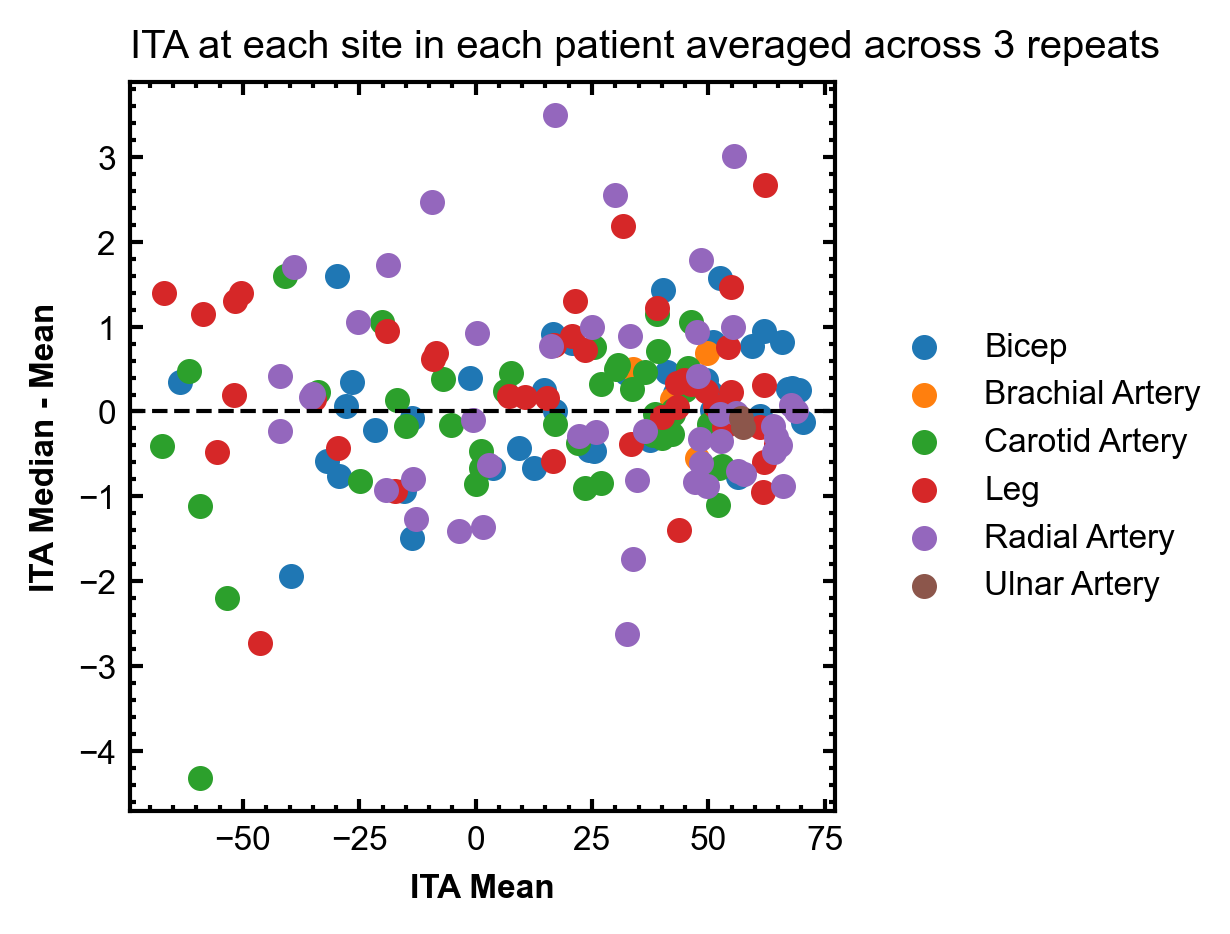

In [13]:
fig = plt.figure(figsize=(4, 3))
ax = fig.subplots()

for n, g in df_mean.groupby("Region"):
    i = 0
    for m, gmed in df_median.groupby("Region"):
        if n != m:
            continue
        if i == 0:
            ax.scatter(g["ITA"], gmed["ITA"] - g["ITA"], label=n)
        else:
            ax.scatter(g["ITA"], gmed["ITA"] - g["ITA"])
        i += 1

ax.plot(
    [0, 1],
    [0, 0],
    c="k",
    linestyle="--",
    transform=blended_transform_factory(plt.gca().transAxes, plt.gca().transData),
)
fig.legend(loc="outside center right")
ax.set_ylabel("ITA Median - Mean")
ax.set_xlabel("ITA Mean")
ax.set_title(
    "ITA at each site in each patient averaged across 3 repeats",
    loc="left",
    fontweight="normal",
)
plt.show()

In [14]:
df_std = df_full[columns].groupby(columns[:4]).std()

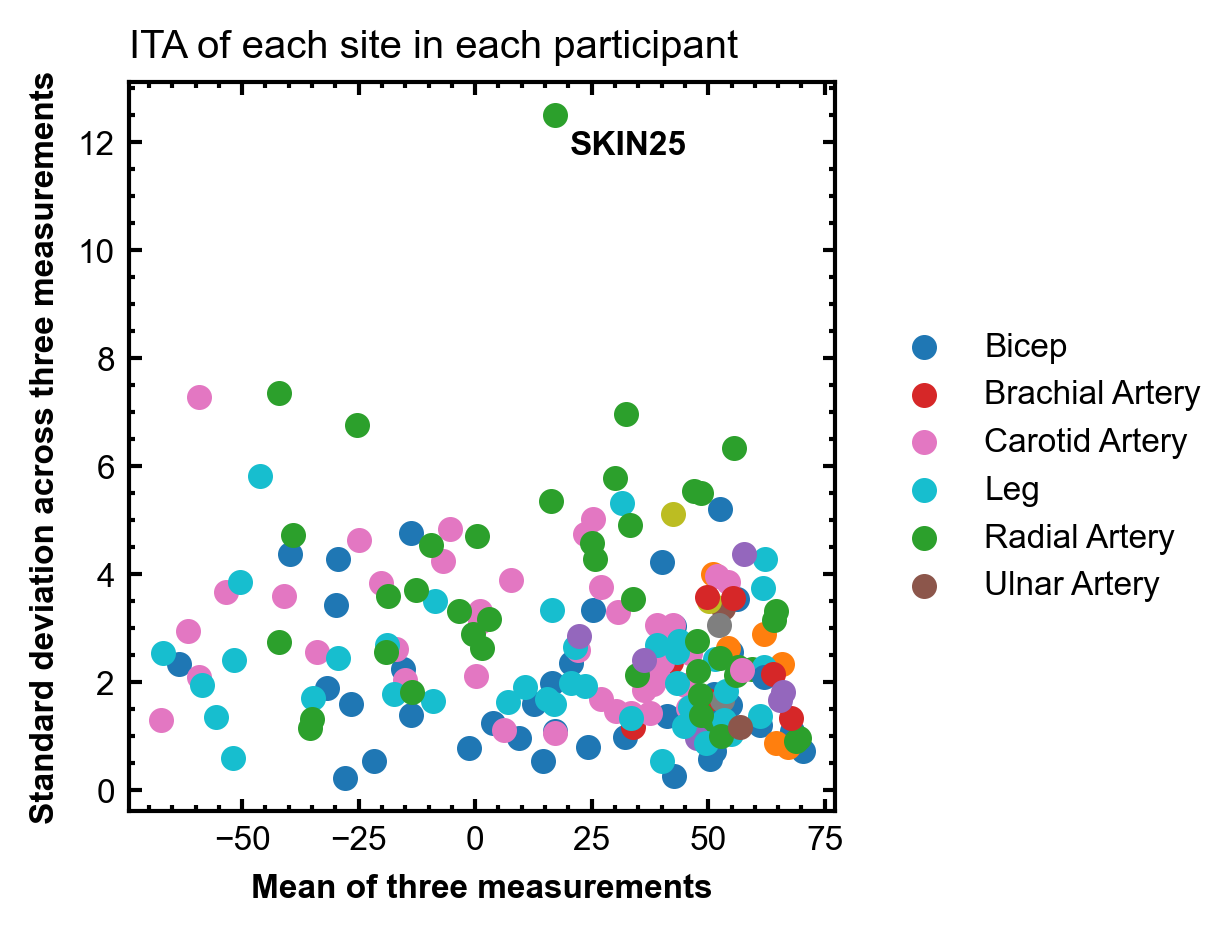

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))

ns = set()
for n, g in df_mean.groupby(["Region", "Side"]):  # type:ignore
    i = 0
    for m, gstd in df_std.groupby(["Region", "Side"]):  # type:ignore
        if n != m:
            continue
        if n[0] not in ns:
            ax.scatter(g["ITA"], gstd["ITA"], label=n[0])
        else:
            ax.scatter(g["ITA"], gstd["ITA"])
        ns.add(n[0])
        if n[0] == "Radial Artery" and n[1] == "":
            row_max = gstd["ITA"].argmax()
            row = gstd.iloc[row_max]
            # print(row)
            offset = ScaledTranslation(0.5e-1, -0.5e-1, fig.dpi_scale_trans)
            shadow_transform = ax.transData + offset
            ax.text(
                g["ITA"].iloc[row_max],
                gstd["ITA"].iloc[row_max],
                row.name[0],  # type: ignore
                ha="left",
                va="top",
                transform=ax.transData + offset,
                fontweight="bold",
            )
        i += 1

fig.legend(loc="outside center right")
ax.set_ylabel("Standard deviation across three measurements")
ax.set_xlabel("Mean of three measurements")
ax.set_title("ITA of each site in each participant", loc="left", fontweight="normal")
plt.show()

In [16]:
df25 = df_full[columns].query("SkinID=='SKIN25' & Region=='Radial Artery' & Side==''")

Before item with index 490 was removed above, we visually observed an outlier in the dataset. To confirm statistically that this is probably an outlier, we can check how many standard deviations it is away from the mean of the rest of the samples.

In [17]:
without_outlier_dataset = [27.80, 14.49, 25.74, 20.54]
mean = np.mean(without_outlier_dataset)
sd = np.std(without_outlier_dataset)

outlier_test = -3.32

print((outlier_test - mean) / sd)

-4.944452654608896


In [18]:
df25[df25["ITA"] > 0]["ITA"].std() / 2

2.9731867723594716

In [19]:
df25["ITA"].mean()

17.050000000000004

In [20]:
df25["ITA"].median()

20.54

In [21]:
# df_full.drop(index=490)[columns].query("SkinID=='SKIN25' & Region=='Radial Artery' & Side==''")

In [22]:
df[df["Region"] == "Radial Artery"].sort_values("ITA")

,SkinID,Region,Pigment,Side,ITA,CIE-L*,CIE-a*,CIE-b*,Melanin,Eryth.,sR,sG,sB
168,SKIN38,Radial Artery,,,-42.130000,36.196667,9.550000,15.056667,65.806667,31.416667,114.000000,76.333333,58.666667
176,SKIN40,Radial Artery,,,-42.056667,36.163333,9.220000,15.353333,66.173333,31.143333,113.333333,76.666667,58.000000
172,SKIN39,Radial Artery,,,-39.066667,36.206667,10.056667,16.970000,64.923333,32.326667,115.333333,76.000000,55.000000
154,SKIN35,Radial Artery,,,-35.453333,38.456667,9.683333,16.203333,61.623333,29.900000,120.666667,81.333333,61.333333
180,SKIN41,Radial Artery,,,-34.974000,37.024000,9.644000,18.556000,63.998000,30.432000,117.400000,78.000000,54.400000
131,SKIN31,Radial Artery,,,-25.390000,42.000000,9.406000,16.900000,57.140000,27.022000,130.400000,90.000000,68.200000
184,SKIN42,Radial Artery,,,-19.218000,43.540000,9.488000,18.542000,53.160000,27.328000,135.200000,93.600000,69.000000
116,SKIN29,Radial Artery,,,-18.738000,43.346000,9.984000,19.604000,54.264000,26.108000,135.800000,92.400000,67.000000
87,SKIN22,Radial Artery,,,-13.534000,45.398000,9.028000,19.082000,52.320000,24.872000,140.000000,98.400000,72.200000
31,SKIN08,Radial Artery,,,-12.792000,45.720000,10.712000,18.738000,48.488000,28.428000,143.200000,98.000000,73.600000
